In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.plot import plot_graph
import random as rng

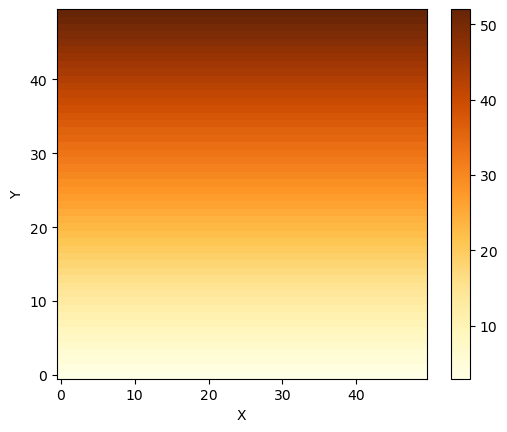

In [8]:
num_rows = 50  # number of grid rows
num_cols = 50  # number of grid columns
dxy = 1  # resolution of raster cell [m], or node horizontal and vertical spacing
grid = RasterModelGrid((num_rows, num_cols), dxy)

#create the initial simplified ramp topography
topo = grid.add_zeros('topographic__elevation', at='node')
cliff_height = 3 #working in meters
for i in range(num_rows):
    start = i * num_rows
    end = start + num_rows
    topo[start:end] = cliff_height
    cliff_height += 1
    
# Plot the topo map
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

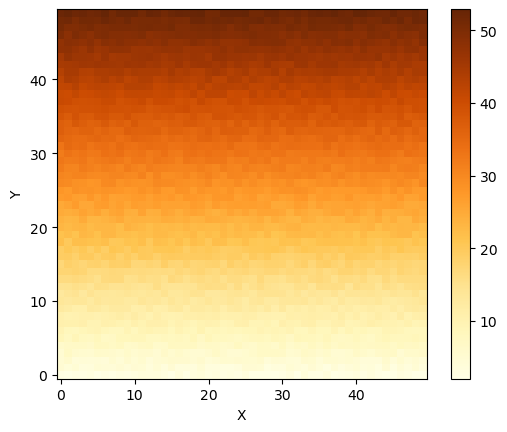

In [9]:
topo_noise = np.random.uniform(-1, 1, 2500)
topo += topo_noise

# Plot the topo map with noise
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

In [10]:
sea_level = 6.0 #meters
erosion_rate = 10  #m/y or set zr[i] = sea_level to cut/flatten directly
uplift_rate_m_yr = 2.1/1000 # 2.1 mm/yr avg uplift
dt = 1000 # timestep (yr)
uplift = uplift_rate_m_yr * dt
time_to_run = 1e6  # time for the model loop to run [yr]
nsteps = int(time_to_run / dt)  # number of model time steps

In [33]:
for step in range (nsteps):
    # Loop over every node on the grid (removed the + 1)
    for i in range(grid.number_of_nodes):
        topo[i]+= uplift
        if topo[i] < sea_level:
            topo[i] -= erosion_rate  # Erode node if it is underwater

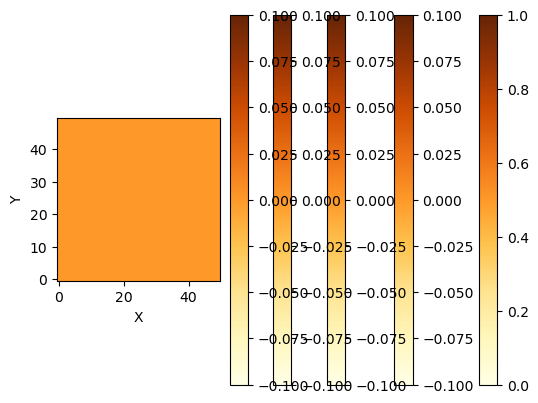

In [11]:
#ethans test
for step in range(5):
    topo += uplift
    #create boolian vector that shows which nodes are below sea level
    is_wet = np.where(topo < sea_level,1,0)
    #erode the nodes that are under sea level
    if is_wet:
        
# plotting
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

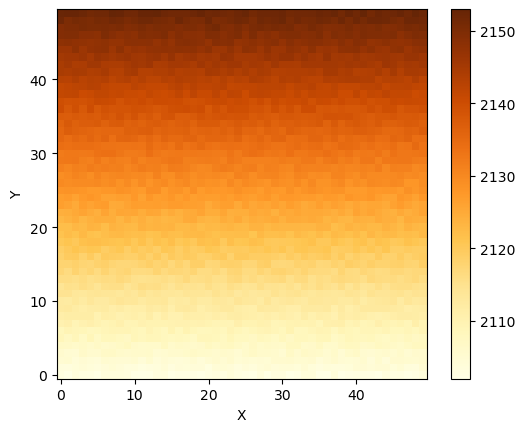

In [7]:
imshow_grid(grid, "topographic__elevation",cmap="YlOrBr")

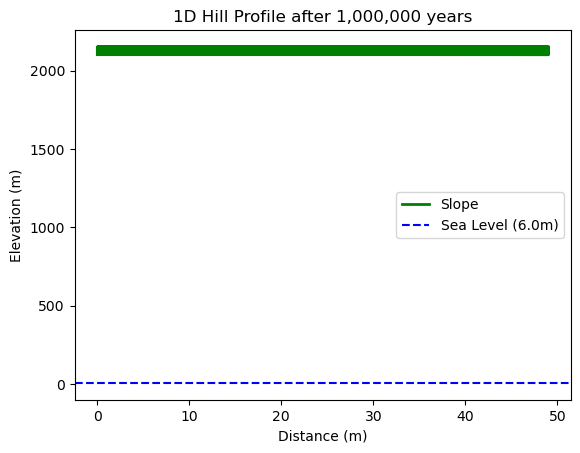

In [24]:
plt.plot(grid.node_x, topo, color='green', linewidth=2, label='Slope')
plt.axhline(sea_level, color='blue', linestyle='--', label='Sea Level (6.0m)')
plt.title(f'1D Hill Profile after {time_to_run:,.0f} years')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.legend()
plt.show()

In [25]:
grid.node_x()

AttributeError: 'RasterModelGrid' object has no attribute 'nodex'